# GIF-corrected mirror Manhattans + QQ — SNP vs SV, LFMM, clq0.9 TILING, all 20 axes

Tiling twin of `gif_manhattan_snp_vs_sv_lfmm.ipynb` (strict clq0.9). Per axis x class:
lambda = median chi2(1df) / 0.4549; if **lambda > 1** the statistics are deflated
(chi2 -> chi2/lambda) and p recomputed; if **lambda <= 1 the axis is LEFT
UNCORRECTED** — dividing by lambda<1 would inflate the signal (bio19 here, lambda~0.9-0.97
across classes). SNP up, sv down. Dashed = per-class Bonferroni. Vertical dotted +
gene label = a tiling block whose lead sv record is Bonferroni-sig (corrected) while
its lead SNP record in the same block is not. QQ (right) shows lambda before->after.

**Headline (checked numerically before building this): 19/20 axes have lambda>1.
Once corrected, SNP and smallindel drop to ZERO Bonferroni-sig records on every axis.
Only SV survives (4 Bonferroni / 13 FDR total, all season), almost entirely
concentrated at one Chr4 receptor-kinase (CRK33/34) tandem-array locus hit by bio6 and
pc1 — no coherent stress/flowering theme (checked against genome background rate).**

In [1]:
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import lib
GEA = lib.GEA
WZAIN = f"{GEA}/phase1_replication/results/multiaxis/wza_in_clq09_tile"
AXES = [f"bio{i}" for i in range(1, 20)] + ["pc1"]
MODEL = "lfmm"
CLS = "sv"
CHROM_LEN = {"Chr1":30427671,"Chr2":19698289,"Chr3":23459830,"Chr4":18585056,"Chr5":26975502}
CH = list(CHROM_LEN); OFF = {}; _a = 0
for _c in CH: OFF[_c] = _a; _a += CHROM_LEN[_c]
plt.rcParams.update({"figure.dpi":110})
SNP_DARK, SNP_LIGHT = "#495057", "#ADB5BD"
CLS_DARK  = "#c0392b" if CLS == "sv" else "#1B5E20"
CLS_LIGHT = "#e8a58c" if CLS == "sv" else "#66BB6A"

def block_spans_tiling(r2=0.9):
    """Tiling block spans: each block absorbs the preceding gap (matches reblock_blockdef.py)."""
    tag=f"clq{r2}"; rows=[]
    for ci in range(1,6):
        ch = f"Chr{ci}"
        g=pd.read_csv(f"{lib.CLQ_BLOCKS_DIR}/chr{ci}_{tag}_blocks_{tag}.tsv",sep="\t").sort_values("start_pos").reset_index(drop=True)
        ends = g.end_pos.to_numpy(np.int64)
        for i in range(len(g)):
            lo = 1 if i == 0 else int(ends[i-1]) + 1
            hi = int(ends[i]) if i < len(g)-1 else 10**9
            rows.append((f"{ch}_{i}", ch, lo, hi))
    return pd.DataFrame(rows,columns=["block","chrom","start","end"]).set_index("block")
SPANS=block_spans_tiling(); GENES=lib.load_genes()
def genes_on(block):
    if block not in SPANS.index: return []
    s=SPANS.loc[block]; gc=GENES[(GENES.chrom==s.chrom)&(GENES.end>=s.start)&(GENES.start<=s.end)]
    return list(gc.gene)
_EXP_MED = stats.chi2.isf(0.5, 1)   # 0.4549..., expected median chi2(1df)
print("loaded:", len(SPANS), "tiling blocks,", len(GENES), "genes ; class =", CLS)

loaded: 58376 tiling blocks, 27206 genes ; class = sv


/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


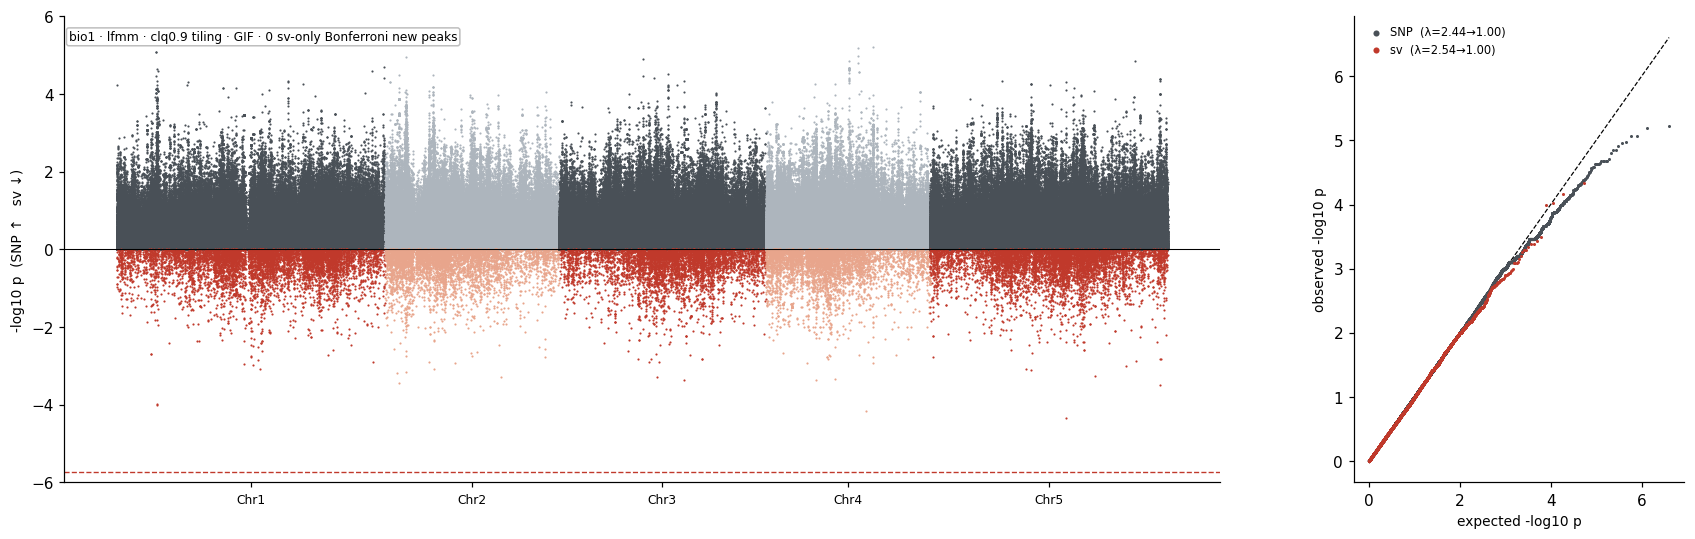

/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


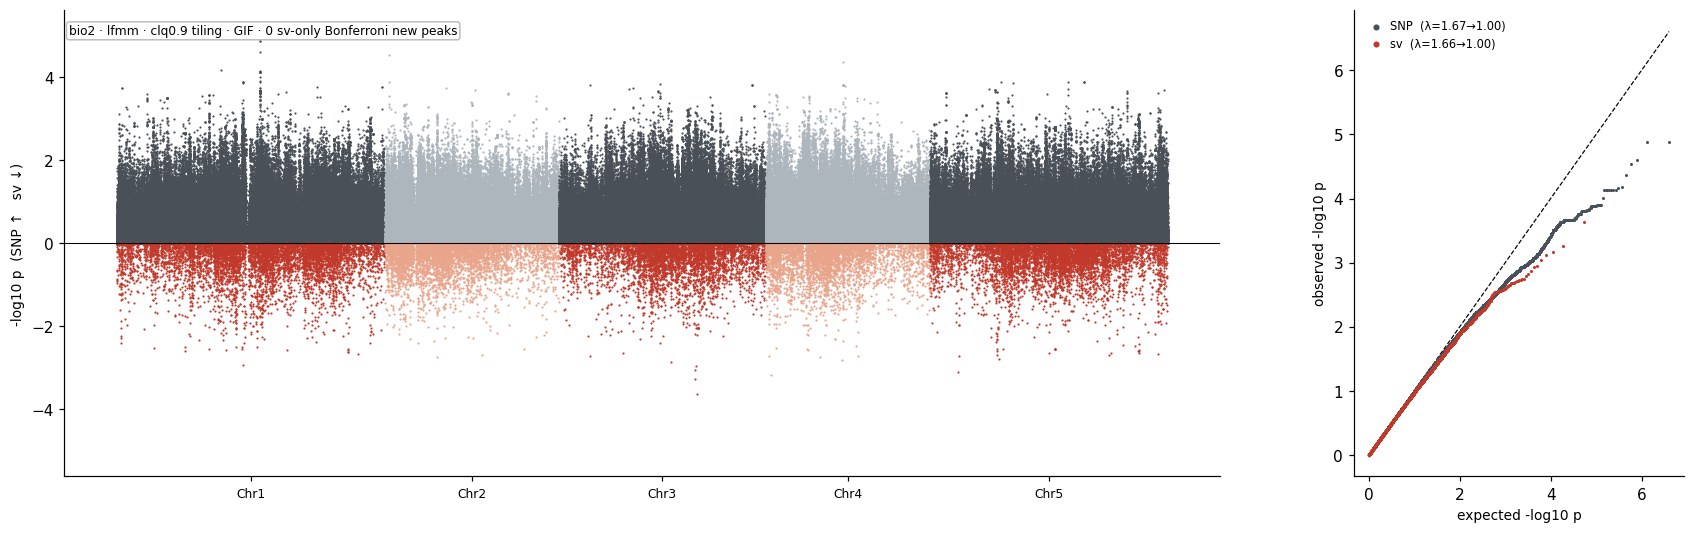

/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


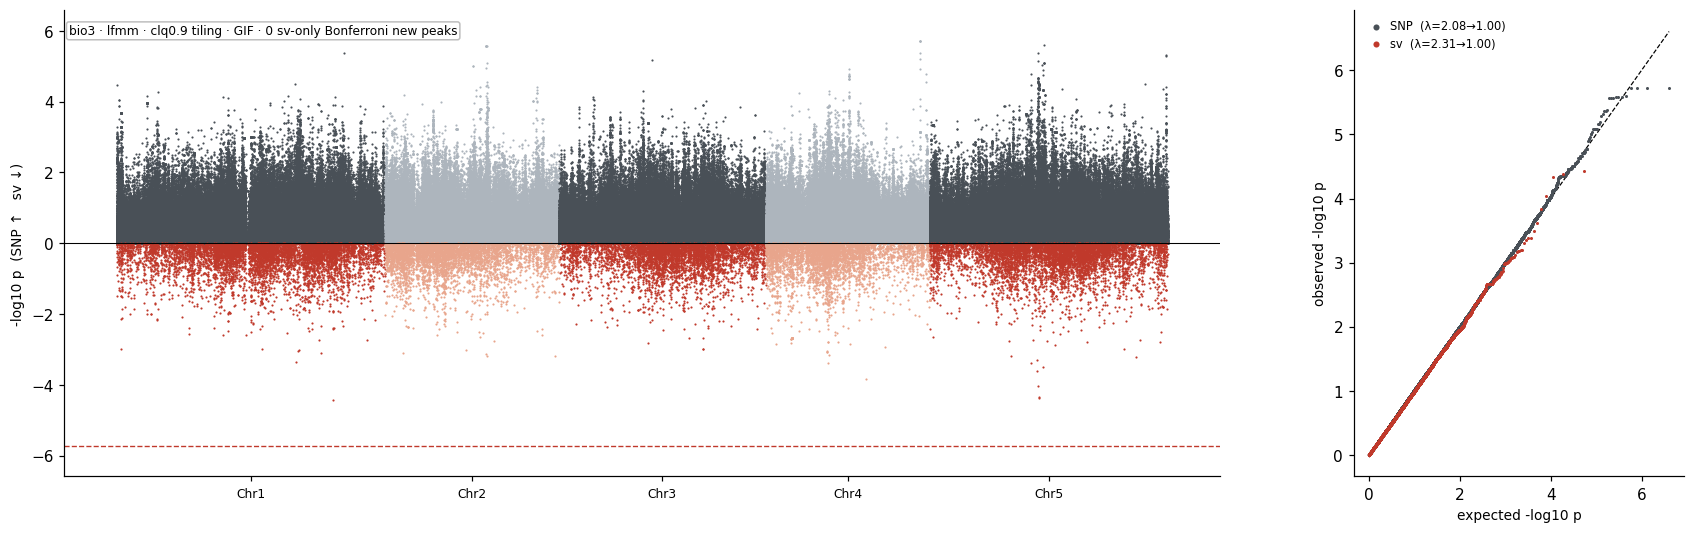

/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


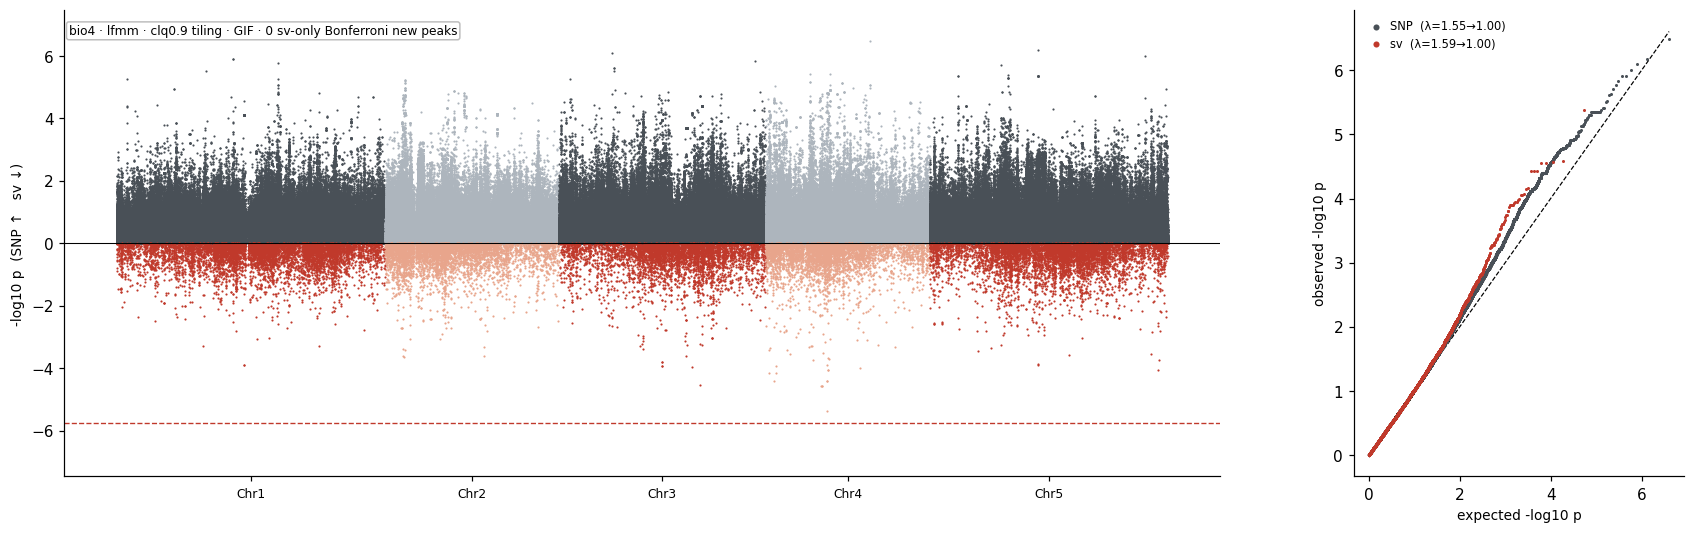

/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


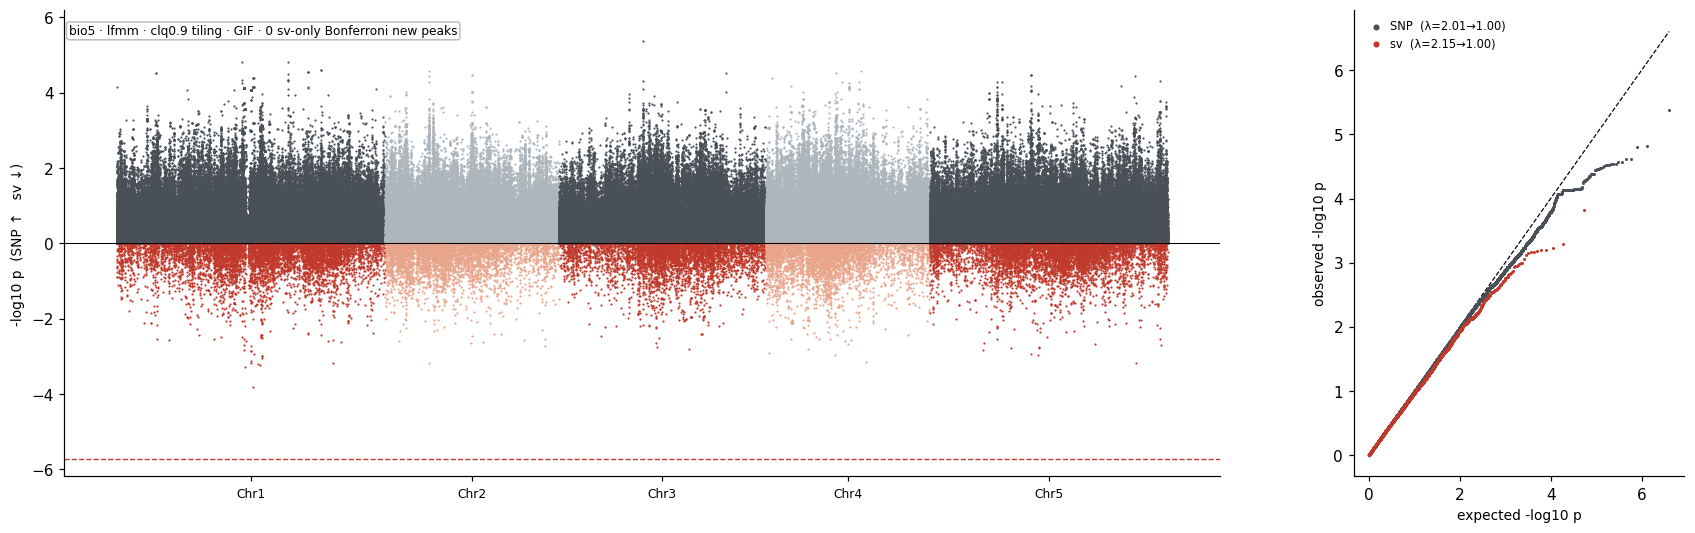

/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


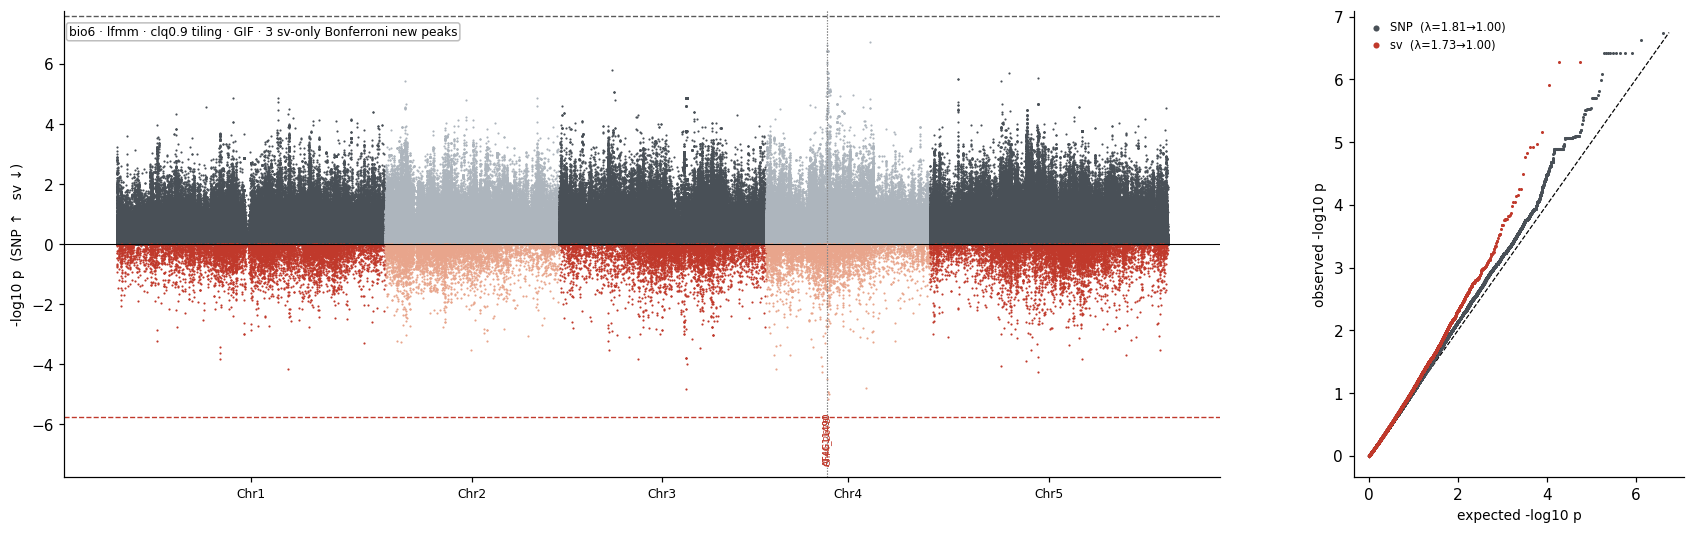

/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


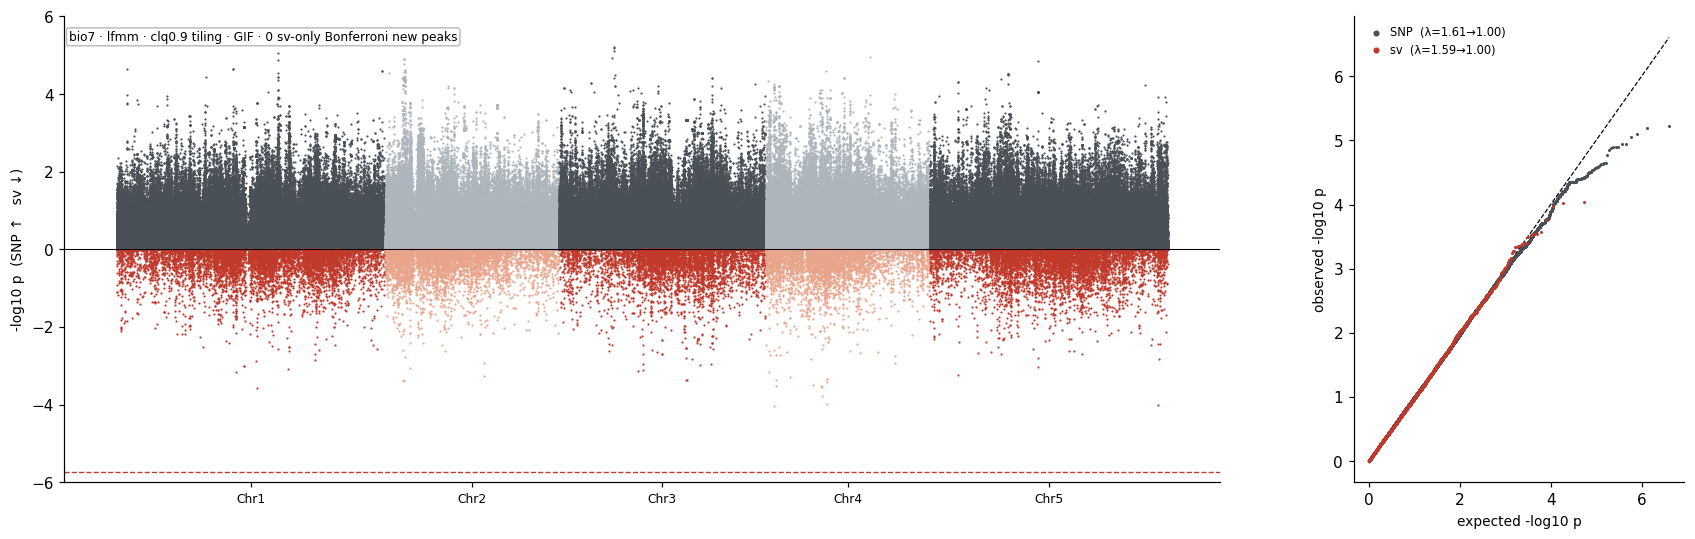

/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


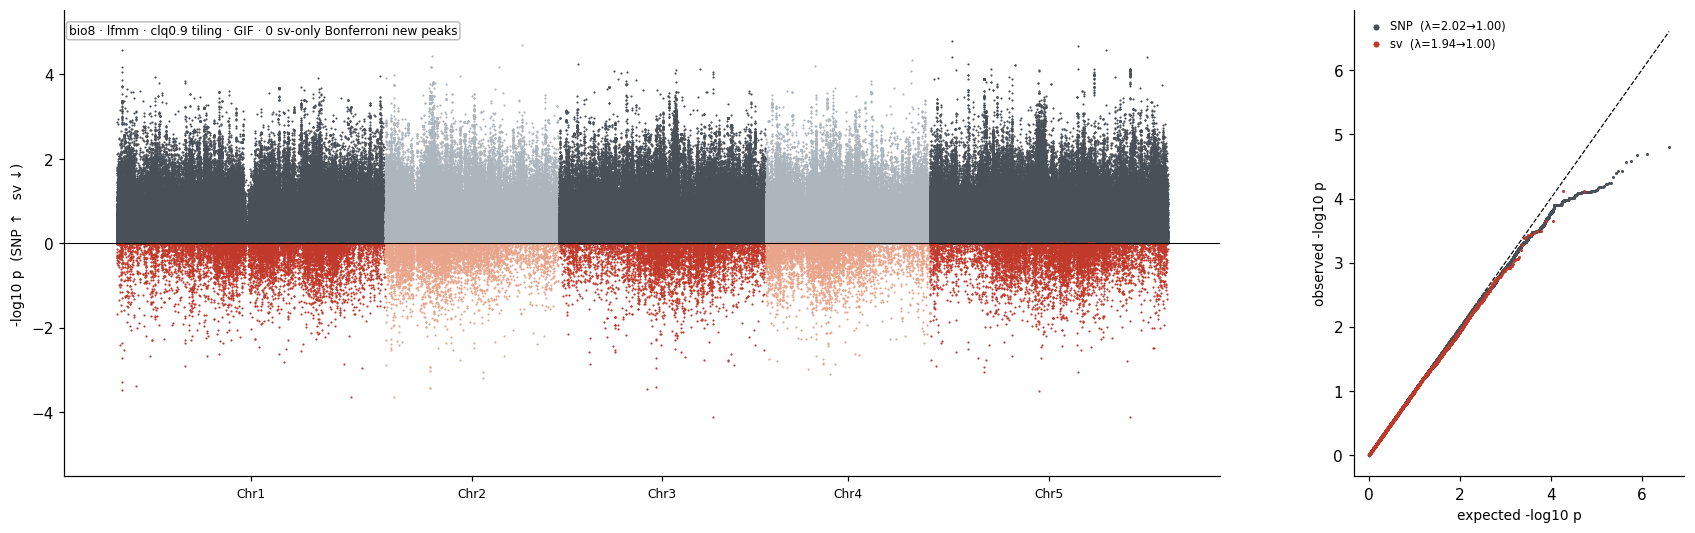

/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


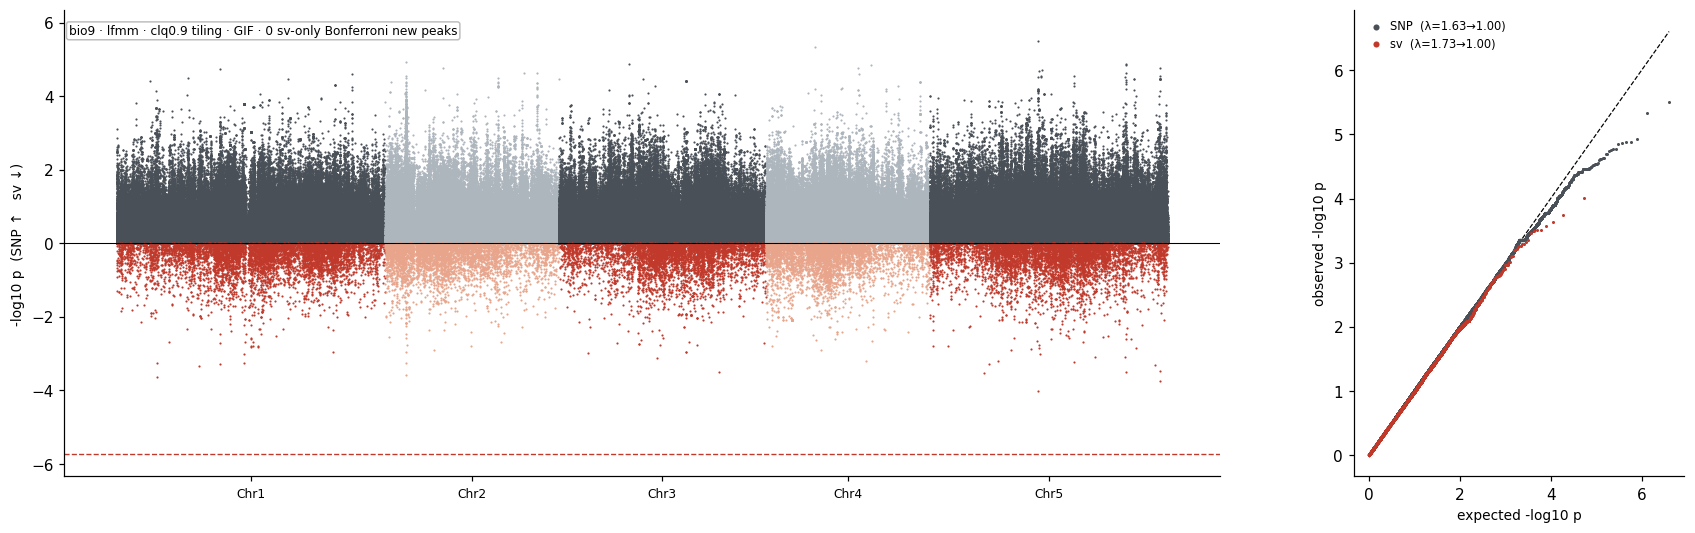

/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


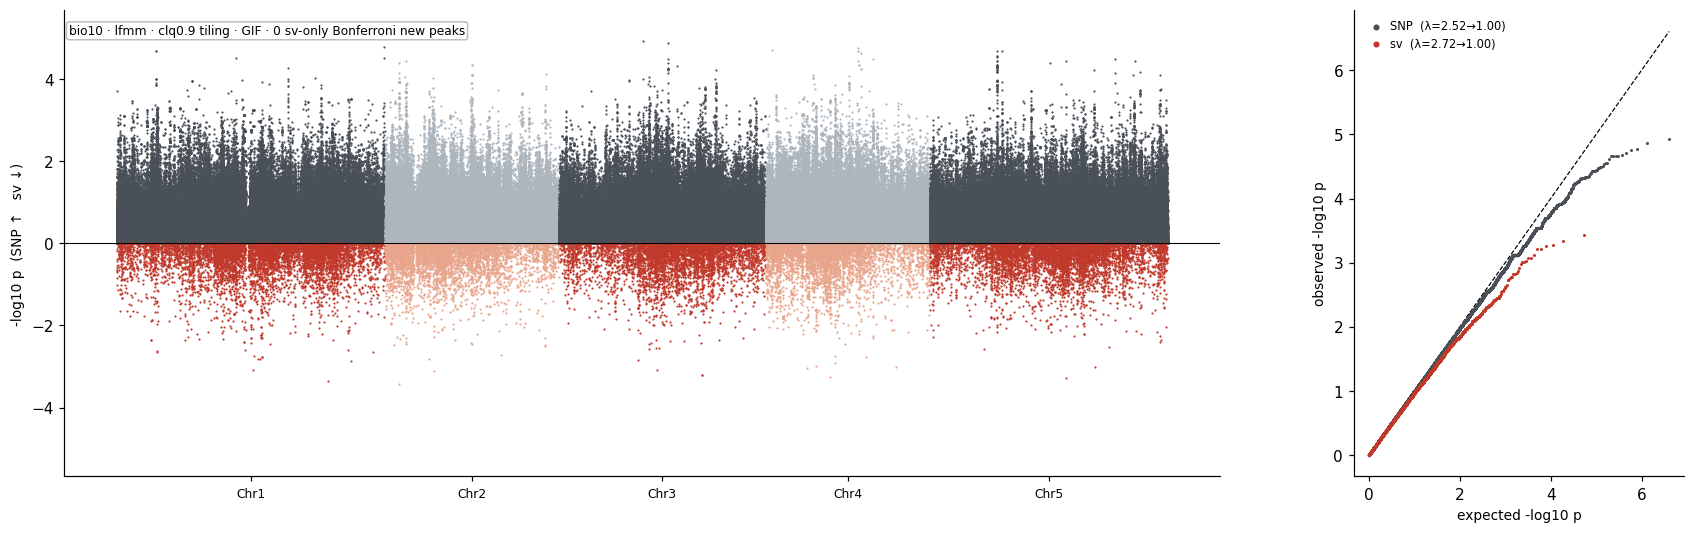

/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


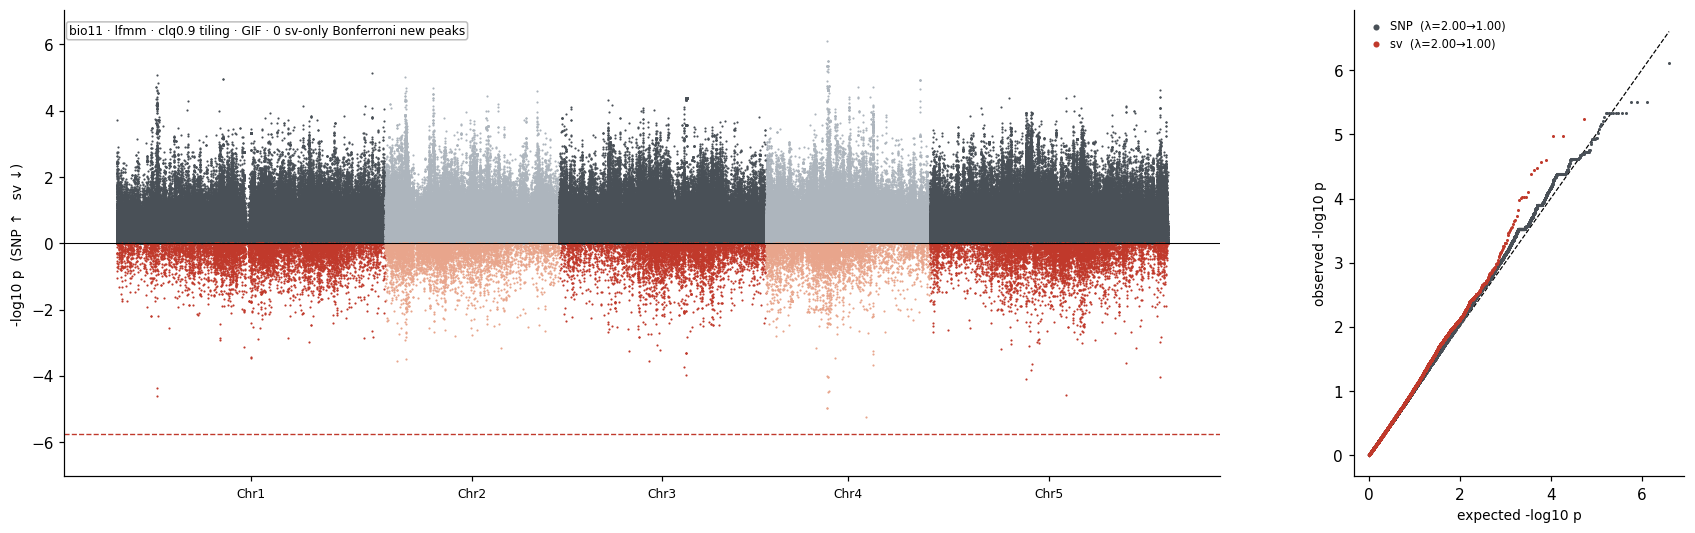

/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


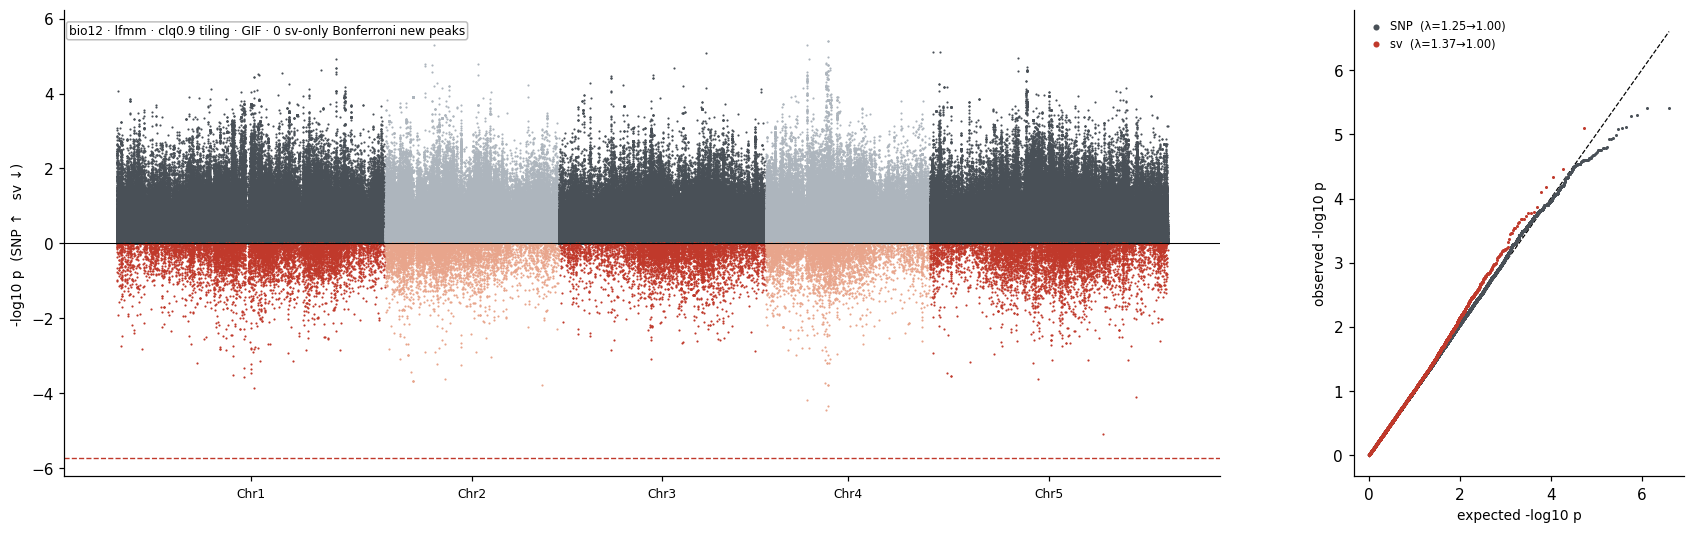

/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


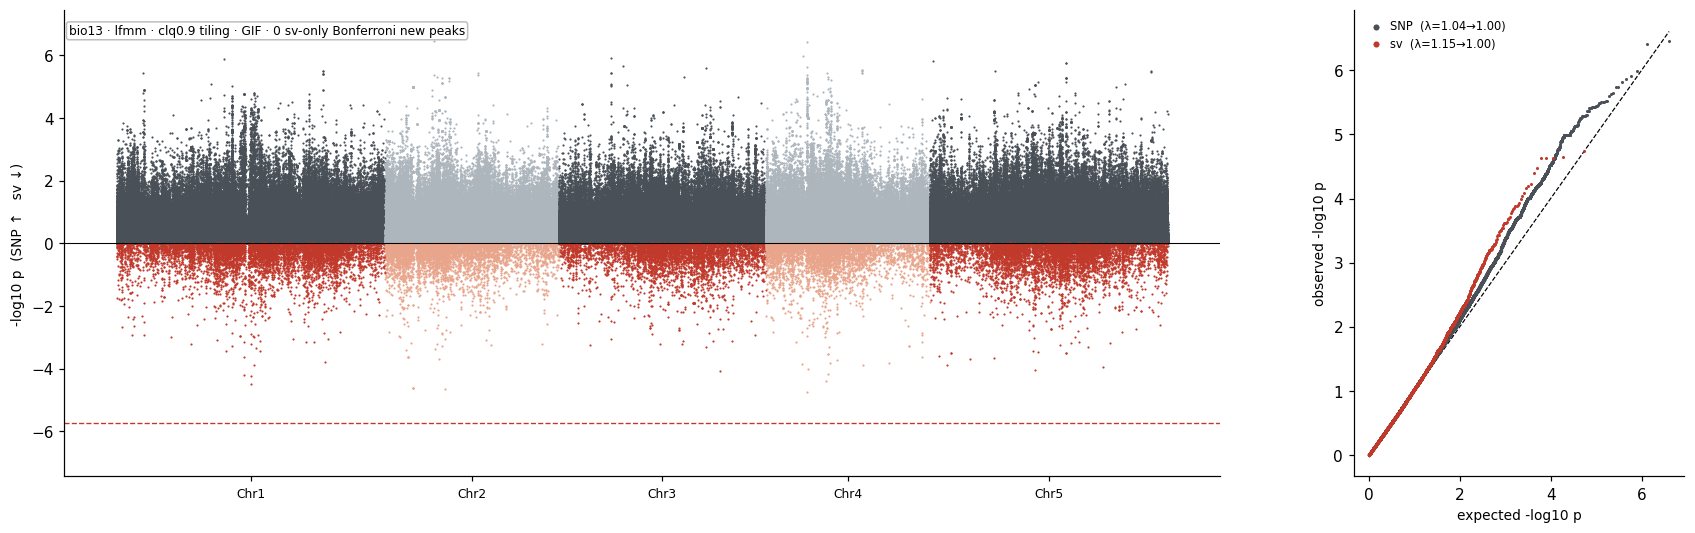

/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


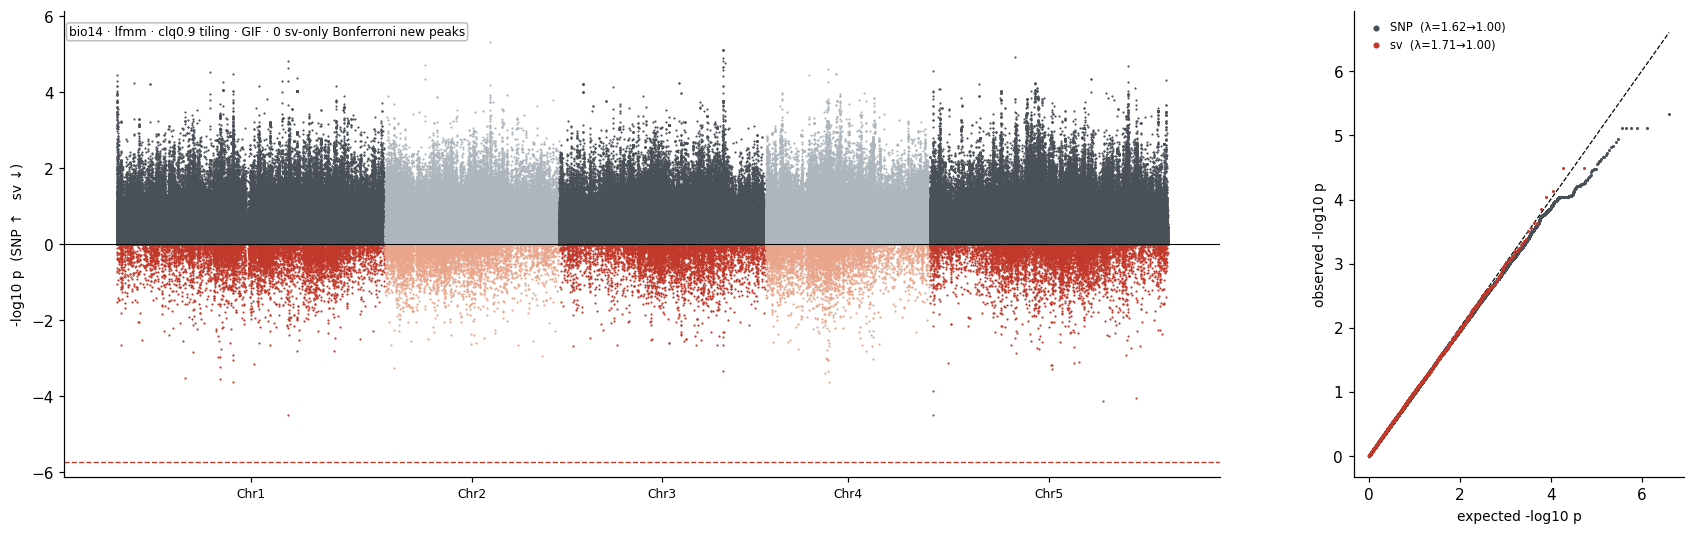

/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


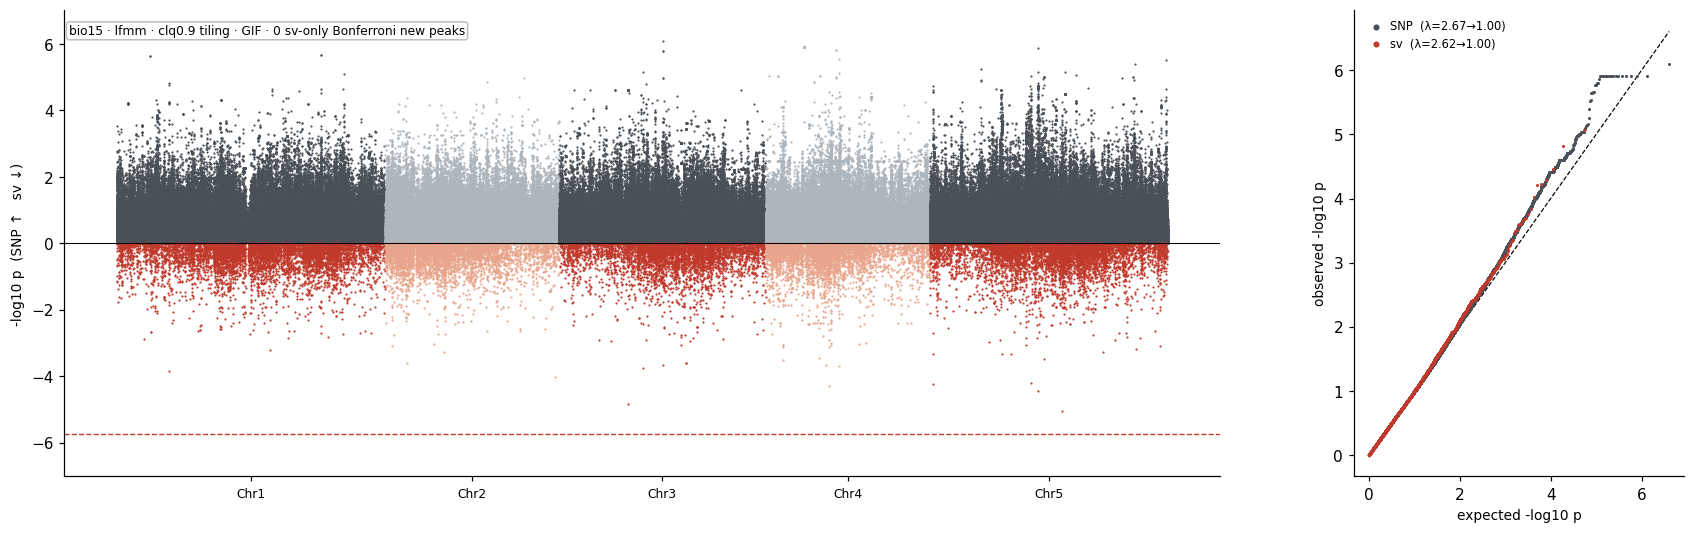

/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


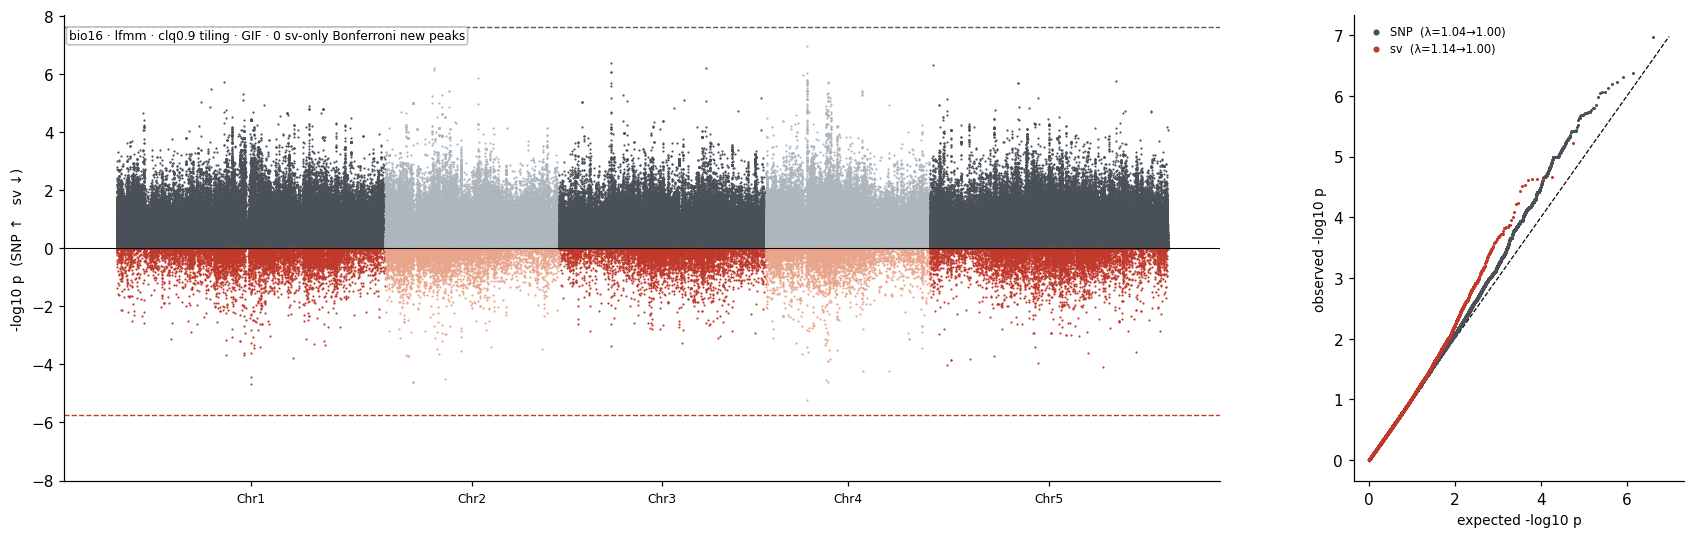

/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


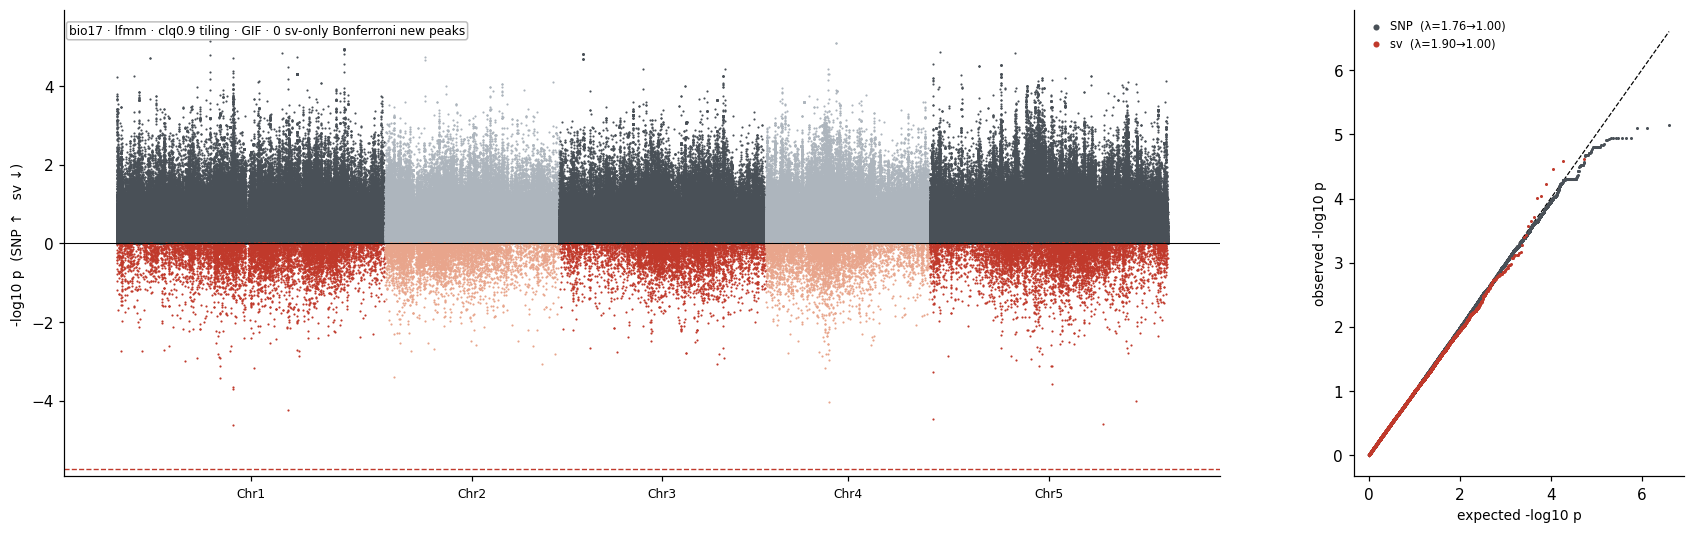

/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


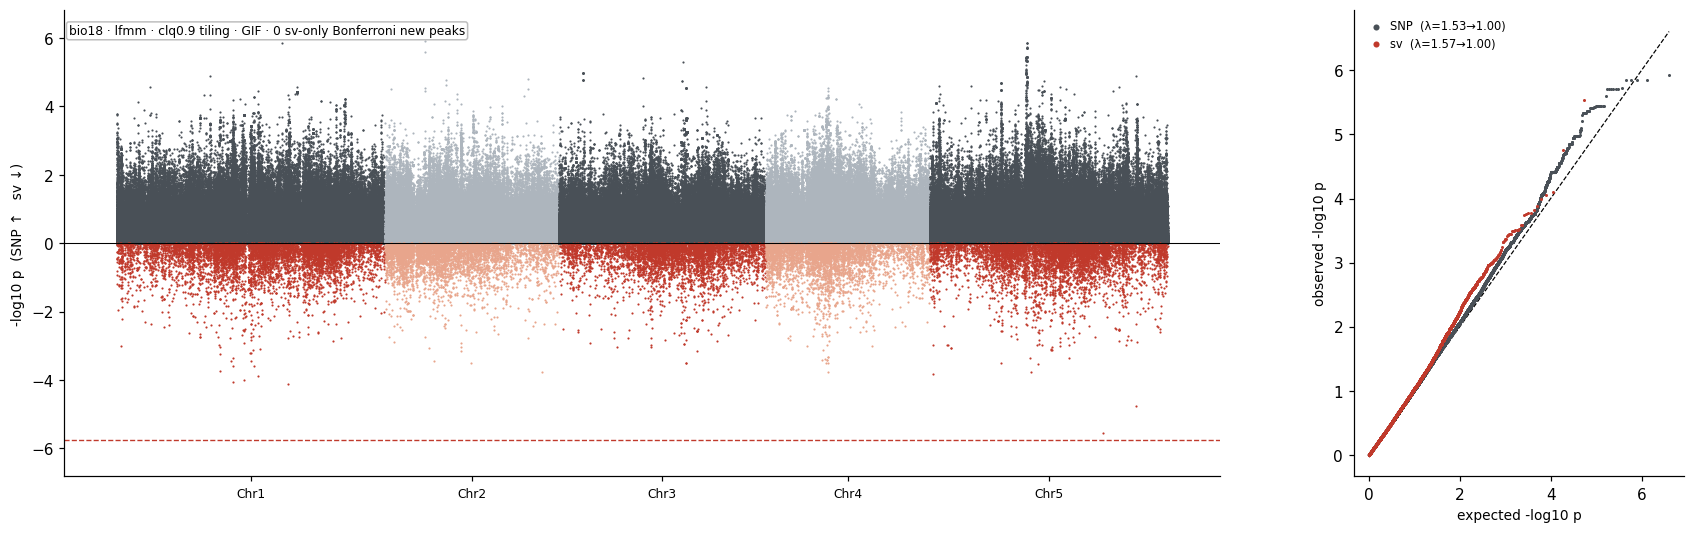

/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


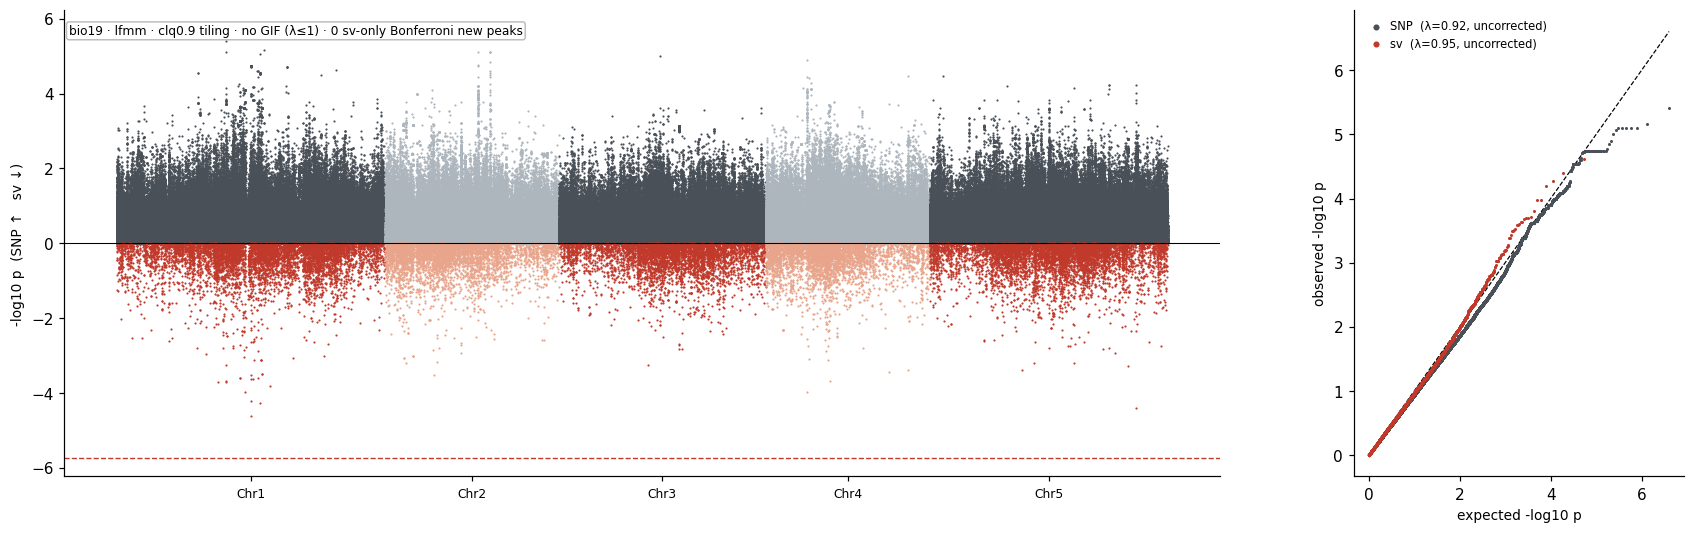

/tmp/ipykernel_3580920/2940781553.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


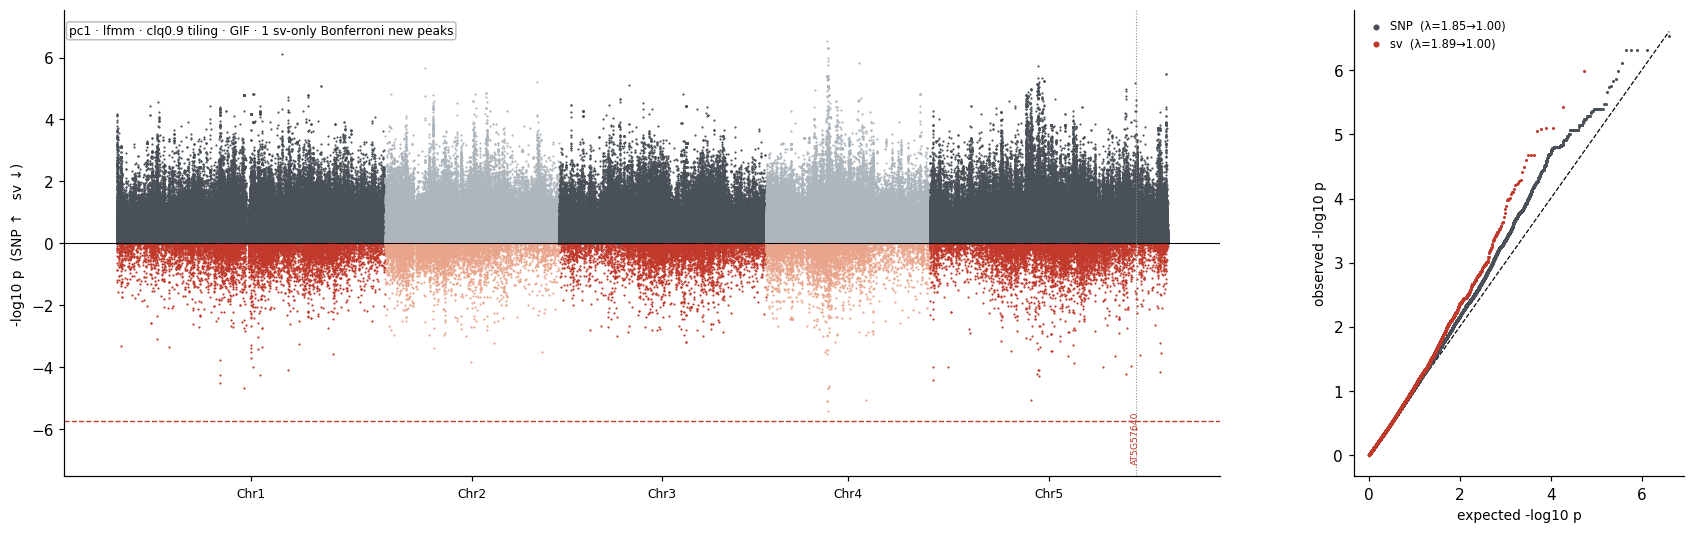

In [2]:
def gif_correct(pval):
    # returns (p_used, lam_pre, lam_post, applied). GIF only when lam_pre>1 (deflation).
    p = np.clip(np.asarray(pval, float), 1e-300, 1.0)
    chi2 = stats.chi2.isf(p, 1)
    lam = float(np.median(chi2) / _EXP_MED)
    if lam > 1.0:
        pc = np.clip(stats.chi2.sf(chi2 / lam, 1), 1e-300, 1.0)
        lam_post = float(np.median(stats.chi2.isf(pc, 1)) / _EXP_MED)
        return pc, lam, lam_post, True
    return p, lam, lam, False           # lam<=1: leave raw (correcting would inflate)

def load_corr(cls, axis):
    f = f"{WZAIN}/{MODEL}_{cls}_gen9_{axis}.csv"
    if not os.path.exists(f): return None
    d = pd.read_csv(f)
    d = d[d["MAF"] > 0.05].copy()
    p_used, lam_pre, lam_post, applied = gif_correct(d["pval"].to_numpy())
    d["p_used"] = p_used
    d["nlp"] = -np.log10(np.clip(p_used, 1e-300, 1.0))
    d["gpos"] = d["chrom"].map(OFF) + d["pos"]
    d.attrs.update(lam_pre=lam_pre, lam_post=lam_post, applied=applied)
    return d

def leads(d):
    d = d[d["block"].notna() & (d["block"] != "")]
    return d.loc[d.groupby("block")["nlp"].idxmax()]

def qq_xy(p, keep_head=15000, n_bulk=3000):
    p = np.sort(np.clip(np.asarray(p, float)[np.isfinite(p)], 1e-300, 1.0))
    n = len(p); exp = -np.log10((np.arange(n) + 0.5) / n); obs = -np.log10(p)
    if n <= keep_head + n_bulk: idx = np.arange(n)
    else:
        idx = np.concatenate([np.arange(keep_head),
                              np.unique(np.geomspace(keep_head, n - 1, n_bulk).astype(int))])
    return exp[idx], obs[idx]

def lam_tag(name, d):
    a, b = d.attrs["lam_pre"], d.attrs["lam_post"]
    return f"{name}  (\u03bb={a:.2f}\u2192{b:.2f})" if d.attrs["applied"] else f"{name}  (\u03bb={a:.2f}, uncorrected)"

def mirror(ax, axis, cls, s, c):
    bonf_s, bonf_c = -np.log10(0.05/len(s)), -np.log10(0.05/len(c))
    ls_, lc_ = leads(s), leads(c)
    m = lc_.merge(ls_[["block", "nlp"]], on="block", suffixes=("", "_snp"), how="left")
    m["nlp_snp"] = m["nlp_snp"].fillna(0.0)
    newpk = m[(m["nlp"] > bonf_c) & (m["nlp_snp"] <= bonf_s)]
    for i, ch in enumerate(CH):
        ss, cc = s[s.chrom == ch], c[c.chrom == ch]
        ax.scatter(ss.gpos, ss.nlp, s=2, c=(SNP_DARK if i % 2 == 0 else SNP_LIGHT), rasterized=True, linewidths=0)
        ax.scatter(cc.gpos, -cc.nlp, s=2, c=(CLS_DARK if i % 2 == 0 else CLS_LIGHT), rasterized=True, linewidths=0)
    ax.axhline(0, c="k", lw=.7); ax.axhline(bonf_s, ls="--", c="0.35", lw=.9); ax.axhline(-bonf_c, ls="--", c=CLS_DARK, lw=.9)
    ymax = max(s.nlp.max(), c.nlp.max()) * 1.15
    for _, r in newpk.iterrows():
        gs = genes_on(r.block); lab = gs[0] if gs else r.block
        ax.axvline(r.gpos, ls=":", c="0.55", lw=.7)
        ax.annotate(lab, xy=(r.gpos, -ymax*0.95), ha="center", va="bottom", fontsize=6, color=CLS_DARK, rotation=90)
    ax.set_ylim(-ymax, ymax); ax.set_xticks([OFF[c]+CHROM_LEN[c]/2 for c in CH]); ax.set_xticklabels(CH, fontsize=8)
    ax.set_ylabel(f"-log10 p  (SNP \u2191   {cls} \u2193)", fontsize=9)
    gtxt = "GIF" if (s.attrs["applied"] or c.attrs["applied"]) else "no GIF (\u03bb\u22641)"
    ax.annotate(f"{axis} \u00b7 lfmm \u00b7 clq0.9 tiling \u00b7 {gtxt} \u00b7 {len(newpk)} {cls}-only Bonferroni new peaks",
                xy=(0.004, 0.97), xycoords="axes fraction", va="top", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.7", alpha=.85))
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    return len(newpk)

def qq(ax, cls, s, c):
    xs, ys = qq_xy(s["p_used"].to_numpy()); xc, yc = qq_xy(c["p_used"].to_numpy())
    hi = max(xs.max(), ys.max(), xc.max(), yc.max())
    ax.plot([0, hi], [0, hi], c="k", lw=.8, ls="--", zorder=1)
    ax.scatter(xs, ys, s=4, c=SNP_DARK, rasterized=True, linewidths=0, zorder=2, label=lam_tag("SNP", s))
    ax.scatter(xc, yc, s=4, c=CLS_DARK, rasterized=True, linewidths=0, zorder=2, label=lam_tag(cls, c))
    ax.set_xlabel("expected -log10 p", fontsize=9); ax.set_ylabel("observed -log10 p", fontsize=9)
    ax.legend(loc="upper left", frameon=False, fontsize=7.5, markerscale=2, handletextpad=0.3)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

for axis in AXES:
    s, c = load_corr("snp", axis), load_corr(CLS, axis)
    if s is None or c is None:
        print(f"missing {axis}"); continue
    fig = plt.figure(figsize=(19, 5.5))
    gs = fig.add_gridspec(1, 2, width_ratios=[3.5, 1], wspace=0.18)
    mirror(fig.add_subplot(gs[0]), axis, CLS, s, c)
    qq(fig.add_subplot(gs[1]), CLS, s, c)
    fig.tight_layout(); plt.show()